# 08 - Clustering CNEFE 2010 (BA)

Clustering independente dos setores de 2010 usando as features disponíveis:
- `situacao`: 1=urbano, 2=rural/localidade
- `tipo`: tipo do logradouro (RUA, FAZENDA, ESTRADA, AVENIDA, TRAVESSA...)

Depois cruzamos com os clusters de 2022 para construir a **matriz de transição**:
quais setores mudaram de perfil entre os dois momentos?

In [7]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import hdbscan
import umap
from pathlib import Path

con = duckdb.connect()
CNEFE_2010 = "'../data/cnefe_2010/*.snappy.parquet'"
OUTPUT_DIR = Path('../outputs')

In [8]:
# Perfil por setor: proporções de tipo + situacao
df_2010 = con.execute(f"""
    SELECT
        setor AS cod_setor,
        COUNT(*) AS total_enderecos,

        -- situacao
        SUM(CASE WHEN situacao = '1' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_urbano,
        SUM(CASE WHEN situacao = '2' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rural,

        -- tipos urbanos
        SUM(CASE WHEN tipo = 'RUA'      THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rua,
        SUM(CASE WHEN tipo = 'AVENIDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_avenida,
        SUM(CASE WHEN tipo = 'TRAVESSA' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_travessa,
        SUM(CASE WHEN tipo = 'PRACA'    THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_praca,
        SUM(CASE WHEN tipo = 'ALAMEDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_alameda,
        SUM(CASE WHEN tipo = 'BECO'     THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_beco,

        -- tipos rurais
        SUM(CASE WHEN tipo = 'FAZENDA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_fazenda,
        SUM(CASE WHEN tipo = 'ESTRADA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_estrada,
        SUM(CASE WHEN tipo = 'CAMINHO'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_caminho,
        SUM(CASE WHEN tipo = 'RODOVIA'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_rodovia,
        SUM(CASE WHEN tipo = 'SITIO'    THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_sitio,
        SUM(CASE WHEN tipo = 'POVOADO'  THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prop_povoado

    FROM read_parquet({CNEFE_2010})
    WHERE uf = '29'
    GROUP BY setor
    HAVING COUNT(*) >= 5
""").df()

print(f'Setores: {len(df_2010):,}')
df_2010.head()

Setores: 23,763


,cod_setor,total_enderecos,prop_urbano,prop_rural,prop_rua,prop_avenida,prop_travessa,prop_praca,prop_alameda,prop_beco,prop_fazenda,prop_estrada,prop_caminho,prop_rodovia,prop_sitio,prop_povoado
0,291700305000003,255,1.0,0.0,0.894118,0.000000,0.074510,0.031373,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
1,291700305000007,146,1.0,0.0,0.726027,0.273973,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
2,291700305000009,167,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.970060,0.0,0.0,0.0,0.005988,0.0
3,291700305000013,556,0.0,1.0,0.406475,0.271583,0.257194,0.064748,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
4,291700305000019,520,0.0,1.0,0.386538,0.000000,0.000000,0.000000,0.0,0.0,0.613462,0.0,0.0,0.0,0.000000,0.0


In [9]:
FEATURES = [
    'prop_urbano', 'prop_rural',
    'prop_rua', 'prop_avenida', 'prop_travessa', 'prop_praca', 'prop_alameda', 'prop_beco',
    'prop_fazenda', 'prop_estrada', 'prop_caminho', 'prop_rodovia', 'prop_sitio', 'prop_povoado'
]

df_2010 = df_2010.dropna(subset=FEATURES)

scaler = StandardScaler()
X = scaler.fit_transform(df_2010[FEATURES])
print(f'Shape: {X.shape}')

Shape: (23763, 14)


In [10]:
# HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=3,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)
df_2010['cluster'] = clusterer.fit_predict(X)

n_clusters = df_2010['cluster'].nunique() - (1 if -1 in df_2010['cluster'].values else 0)
n_noise    = (df_2010['cluster'] == -1).sum()
print(f'Clusters: {n_clusters}')
print(f'Ruído   : {n_noise:,} ({n_noise/len(df_2010)*100:.1f}%)')
print()
print(df_2010['cluster'].value_counts().sort_index())

Clusters: 12
Ruído   : 14,446 (60.8%)

cluster
-1     14446
 0       266
 1       976
 2      1600
 3       332
 4       677
 5       202
 6       204
 7      1742
 8      1257
 9       300
 10     1546
 11      215
Name: count, dtype: int64


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPERIMENTO: clustering COM posição geográfica vs SEM posição geográfica
#
# O clustering principal (célula acima) usa APENAS proporções de tipo de
# endereço — sem lat/lon. Este experimento adiciona as coordenadas para
# mostrar que a separação urbano/rural emerge das características dos
# endereços, independentemente da posição geográfica.
# ─────────────────────────────────────────────────────────────────────────────

# Adiciona coordenadas normalizadas (de 2022) aos setores de 2010
df_coords = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')[
    ['COD_SETOR', 'lat_centroide', 'lon_centroide']
].copy()
df_coords['cod_setor'] = df_coords['COD_SETOR'].str[:-1]

df_geo = df_2010.merge(df_coords[['cod_setor', 'lat_centroide', 'lon_centroide']],
                       on='cod_setor', how='left')

# Features COM posição geográfica
FEATURES_GEO = FEATURES + ['lat_centroide', 'lon_centroide']
df_geo = df_geo.dropna(subset=FEATURES_GEO)

X_geo = scaler.fit_transform(df_geo[FEATURES_GEO])

clusterer_geo = hdbscan.HDBSCAN(
    min_cluster_size=200, min_samples=3,
    metric='euclidean', cluster_selection_method='eom'
)
labels_geo = clusterer_geo.fit_predict(X_geo)
df_geo['cluster_geo'] = labels_geo

# Silhouette: SEM vs COM coordenadas
mask_sem = df_2010['cluster'] != -1
score_sem = silhouette_score(X[mask_sem], df_2010.loc[mask_sem, 'cluster'],
                             sample_size=5000, random_state=42)

mask_com = df_geo['cluster_geo'] != -1
score_com = silhouette_score(X_geo[mask_com], df_geo.loc[mask_com, 'cluster_geo'],
                             sample_size=5000, random_state=42)

n_sem = df_2010['cluster'].nunique() - (1 if -1 in df_2010['cluster'].values else 0)
n_com = df_geo['cluster_geo'].nunique() - (1 if -1 in labels_geo else 0)
r_sem = (df_2010['cluster'] == -1).sum() / len(df_2010) * 100
r_com = (labels_geo == -1).sum() / len(df_geo) * 100

print('─' * 52)
print(f'{"":25} {"SEM geo":>10} {"COM geo":>10}')
print('─' * 52)
print(f'{"Clusters encontrados":25} {n_sem:>10} {n_com:>10}')
print(f'{"Ruído (%)":25} {r_sem:>9.1f}% {r_com:>9.1f}%')
print(f'{"Silhouette Score":25} {score_sem:>10.4f} {score_com:>10.4f}')
print('─' * 52)
print()
print('→ Se os scores forem próximos, o algoritmo encontrou os mesmos')
print('  padrões sem precisar saber onde os setores estão no mapa.')

────────────────────────────────────────────────────
                             SEM geo    COM geo
────────────────────────────────────────────────────
Clusters encontrados              12          6
Ruído (%)                      60.8%      70.7%
Silhouette Score              0.6724     0.5725
────────────────────────────────────────────────────

→ Se os scores forem próximos, o algoritmo encontrou os mesmos
  padrões sem precisar saber onde os setores estão no mapa.


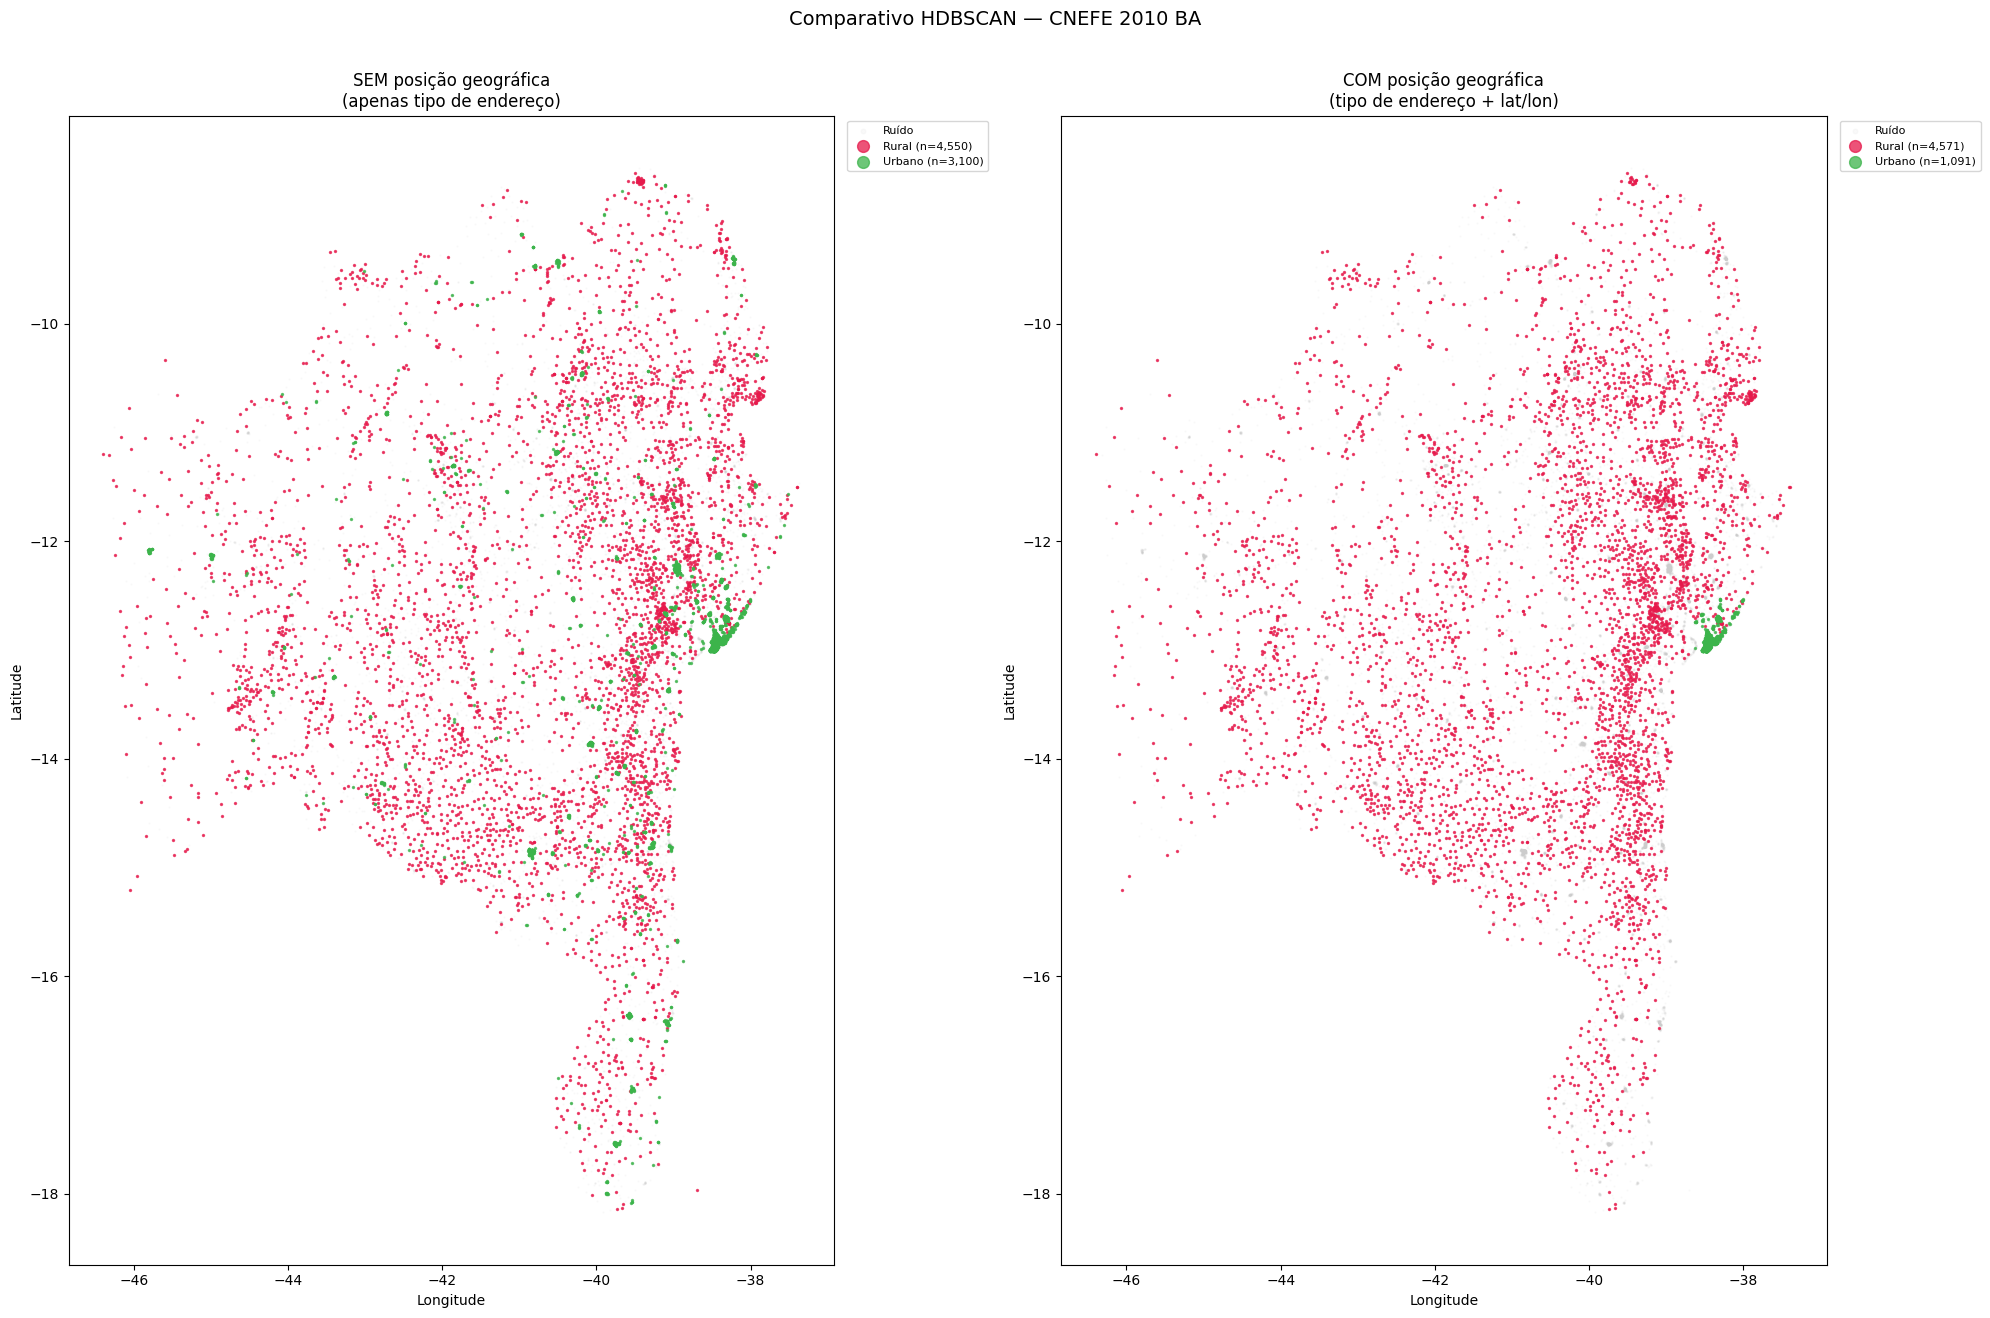

In [12]:
# Variáveis necessárias
CORES_FORTES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
                '#800000','#000075','#ff6b6b','#06d6a0','#ffd166']

NOMES_2010 = {
    'prop_urbano': 'Urbano', 'prop_rural': 'Rural',
    'prop_rua': 'Urbano Residencial', 'prop_avenida': 'Urbano Comercial',
    'prop_travessa': 'Urbano Denso', 'prop_praca': 'Urbano Central',
    'prop_alameda': 'Urbano Residencial', 'prop_beco': 'Urbano Denso',
    'prop_fazenda': 'Rural Agrícola', 'prop_estrada': 'Rural / Peri-urbano',
    'prop_caminho': 'Rural', 'prop_rodovia': 'Peri-urbano',
    'prop_sitio': 'Rural Agrícola', 'prop_povoado': 'Localidade Rural',
}

# Garante cluster_nome em df_2010 independentemente da ordem de execução
if 'cluster_nome' not in df_2010.columns:
    perfil_z_tmp = df_2010[df_2010['cluster'] != -1].groupby('cluster')[FEATURES].mean()
    nomes_tmp = {cid: NOMES_2010[row.idxmax()] for cid, row in perfil_z_tmp.iterrows()}
    df_2010['cluster_nome'] = df_2010['cluster'].map(
        lambda x: nomes_tmp.get(x, 'Ruído') if x != -1 else 'Ruído'
    )

# Constrói df_2010_geo com coordenadas de 2022
df_coords_exp = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')[
    ['COD_SETOR', 'lat_centroide', 'lon_centroide']
].copy()
df_coords_exp['cod_setor'] = df_coords_exp['COD_SETOR'].str[:-1]

df_2010_geo = df_2010.merge(
    df_coords_exp[['cod_setor', 'lat_centroide', 'lon_centroide']],
    on='cod_setor', how='inner'
)

# Nomeia clusters do experimento COM geo
perfil_z_geo = df_geo[df_geo['cluster_geo'] != -1].groupby('cluster_geo')[FEATURES].mean()
nomes_geo = {cid: NOMES_2010[row.idxmax()] for cid, row in perfil_z_geo.iterrows()}
df_geo['cluster_nome_geo'] = df_geo['cluster_geo'].map(
    lambda x: nomes_geo.get(x, 'Ruído') if x != -1 else 'Ruído'
)

# Paleta compartilhada (mesmo nome = mesma cor nos dois mapas)
todos_nomes = sorted(set(
    df_2010_geo[df_2010_geo['cluster'] != -1]['cluster_nome'].unique().tolist() +
    df_geo[df_geo['cluster_geo'] != -1]['cluster_nome_geo'].unique().tolist()
))
palette_exp = {n: CORES_FORTES[i % len(CORES_FORTES)] for i, n in enumerate(todos_nomes)}

fig, axes = plt.subplots(1, 2, figsize=(20, 13))

for ax, titulo, df_plot, col_nome, col_cluster in [
    (axes[0], 'SEM posição geográfica\n(apenas tipo de endereço)',
     df_2010_geo, 'cluster_nome', 'cluster'),
    (axes[1], 'COM posição geográfica\n(tipo de endereço + lat/lon)',
     df_geo,     'cluster_nome_geo', 'cluster_geo'),
]:
    noise = df_plot[df_plot[col_cluster] == -1]
    ax.scatter(noise['lon_centroide'], noise['lat_centroide'],
               s=0.3, c='#cccccc', alpha=0.1, label='Ruído')

    for nome in todos_nomes:
        sub = df_plot[df_plot[col_nome] == nome]
        if len(sub):
            ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
                       s=2, alpha=0.75, color=palette_exp[nome],
                       label=f'{nome} (n={len(sub):,})')

    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

fig.suptitle('Comparativo HDBSCAN — CNEFE 2010 BA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/comparativo_sem_com_geo_2010_ba.png', dpi=150, bbox_inches='tight')
plt.show()

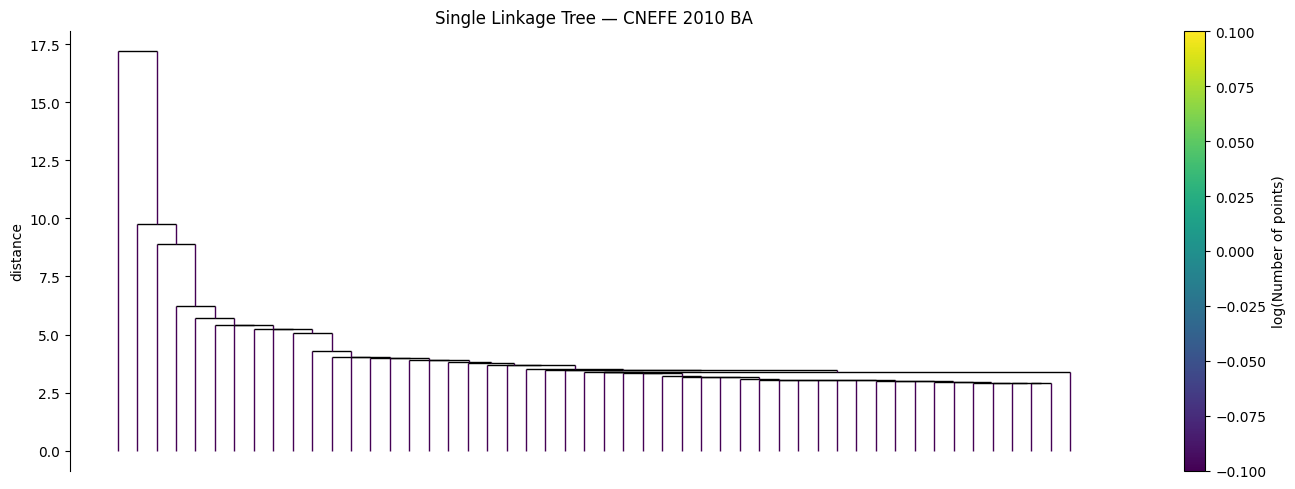

In [13]:
# Single Linkage Tree
fig, ax = plt.subplots(figsize=(14, 5))
clusterer.single_linkage_tree_.plot(
    truncate_mode='lastp', p=50,
    vary_line_width=False,
    cmap='viridis', colorbar=True, axis=ax
)
ax.set_title('Single Linkage Tree — CNEFE 2010 BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/single_linkage_tree_2010_ba.png', dpi=150)
plt.show()

In [14]:
# Silhouette
mask = df_2010['cluster'] != -1
if mask.sum() > 1 and df_2010.loc[mask, 'cluster'].nunique() > 1:
    score = silhouette_score(X[mask], df_2010.loc[mask, 'cluster'], sample_size=10000, random_state=42)
    print(f'Silhouette Score 2010: {score:.4f}')

Silhouette Score 2010: 0.6733


In [15]:
# Nomenclatura dos clusters 2010 — sem sufixo numérico
NOMES_2010 = {
    'prop_urbano':   'Urbano',
    'prop_rural':    'Rural',
    'prop_rua':      'Urbano Residencial',
    'prop_avenida':  'Urbano Comercial',
    'prop_travessa': 'Urbano Denso',
    'prop_praca':    'Urbano Central',
    'prop_alameda':  'Urbano Residencial',
    'prop_beco':     'Urbano Denso',
    'prop_fazenda':  'Rural Agrícola',
    'prop_estrada':  'Rural / Peri-urbano',
    'prop_caminho':  'Rural',
    'prop_rodovia':  'Peri-urbano',
    'prop_sitio':    'Rural Agrícola',
    'prop_povoado':  'Localidade Rural',
}

perfil_z = df_2010[df_2010['cluster'] != -1].groupby('cluster')[FEATURES].mean()

nomes_2010 = {cid: NOMES_2010[row.idxmax()] for cid, row in perfil_z.iterrows()}
df_2010['cluster_nome'] = df_2010['cluster'].map(
    lambda x: nomes_2010.get(x, 'Ruído') if x != -1 else 'Ruído'
)

print('Tipos de cluster 2010:')
tamanhos_nome = df_2010[df_2010['cluster'] != -1]['cluster_nome'].value_counts().sort_index()
for nome, n in tamanhos_nome.items():
    print(f'  {nome:<30} (n={n:,})')

Tipos de cluster 2010:
  Rural                          (n=5,733)
  Urbano                         (n=3,584)


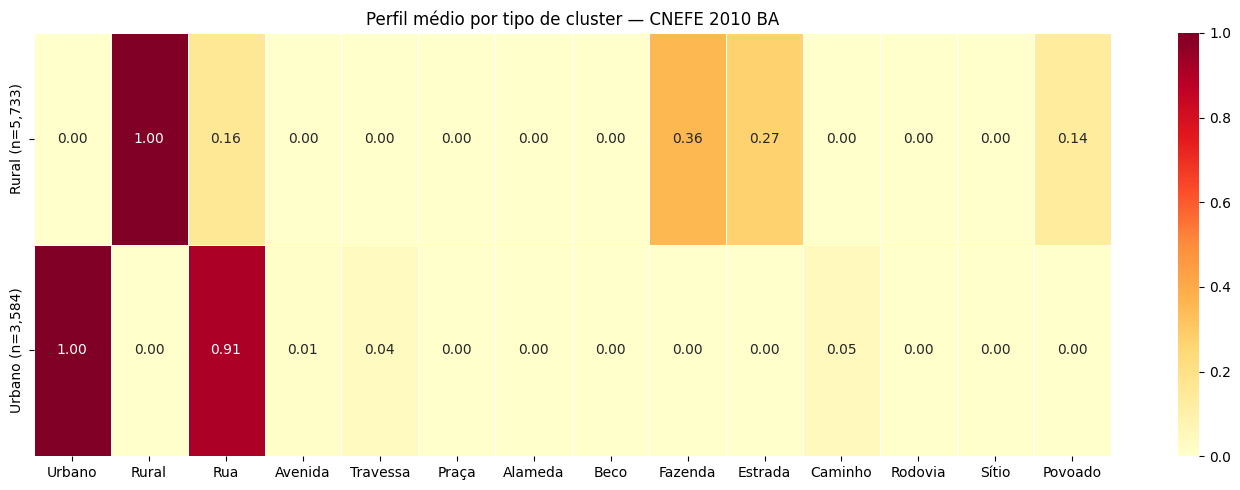

In [16]:
# Heatmap — agrega por cluster_nome (clusters do mesmo tipo unidos)
FEAT_LABEL = {
    'prop_urbano': 'Urbano', 'prop_rural': 'Rural',
    'prop_rua': 'Rua', 'prop_avenida': 'Avenida',
    'prop_travessa': 'Travessa', 'prop_praca': 'Praça',
    'prop_alameda': 'Alameda', 'prop_beco': 'Beco',
    'prop_fazenda': 'Fazenda', 'prop_estrada': 'Estrada',
    'prop_caminho': 'Caminho', 'prop_rodovia': 'Rodovia',
    'prop_sitio': 'Sítio', 'prop_povoado': 'Povoado',
}

perfil = (df_2010[df_2010['cluster'] != -1]
          .groupby('cluster_nome')[FEATURES]
          .mean()
          .rename(columns=FEAT_LABEL))

tamanhos_nome = df_2010[df_2010['cluster'] != -1]['cluster_nome'].value_counts()
perfil.index = [f"{nome} (n={tamanhos_nome[nome]:,})" for nome in perfil.index]

fig, ax = plt.subplots(figsize=(14, max(5, len(perfil) * 0.55 + 1)))
sns.heatmap(perfil, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil médio por tipo de cluster — CNEFE 2010 BA')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/perfil_clusters_2010_ba.png', dpi=150)
plt.show()

Setores com match em ambos os anos: 7,650
  cluster_2010          cluster_2022
0        Rural  Rural / Agropecuário
1        Rural                 Ruído
2        Rural                 Ruído
3        Rural                 Ruído
4        Rural                 Ruído


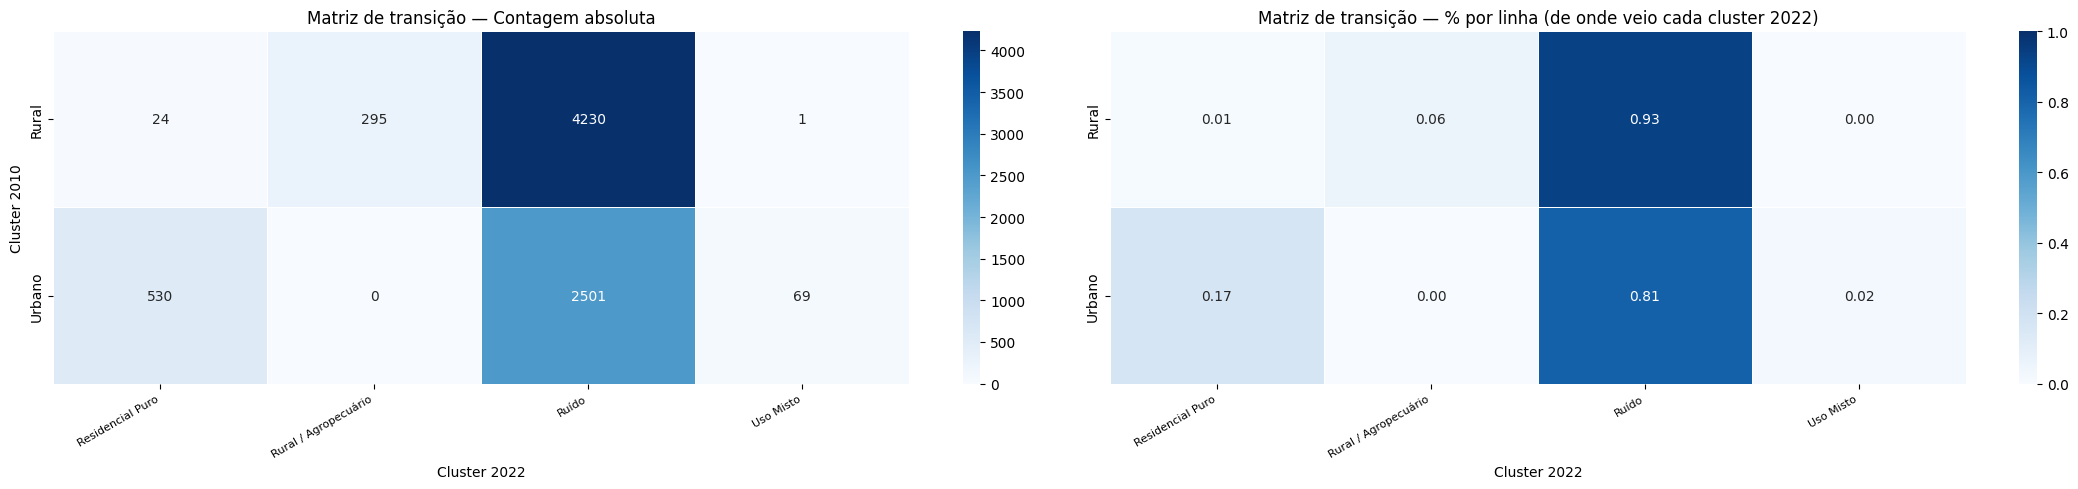

In [17]:
# Matriz de transição: cluster 2010 → cluster 2022
# Carrega direto dos parquets para não depender do estado da sessão
df_2010_saved = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet')
df_2022_saved = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')

# Códigos de 2022 têm sufixo 'P' — removido antes do join
df_2022_saved['cod_setor'] = df_2022_saved['COD_SETOR'].str[:-1]

df_trans = (df_2010_saved[df_2010_saved['cluster'] != -1]
            .merge(
                df_2022_saved[['cod_setor', 'cluster_nome']].rename(columns={'cluster_nome': 'cluster_2022'}),
                on='cod_setor', how='inner'
            )
            .rename(columns={'cluster_nome': 'cluster_2010'}))

print(f'Setores com match em ambos os anos: {len(df_trans):,}')
print(df_trans[['cluster_2010', 'cluster_2022']].head())

matriz_abs = pd.crosstab(df_trans['cluster_2010'], df_trans['cluster_2022'])
matriz_pct = matriz_abs.div(matriz_abs.sum(axis=1), axis=0).round(2)

fig, axes = plt.subplots(1, 2, figsize=(22, max(5, len(matriz_pct) * 0.6 + 1)))

sns.heatmap(matriz_abs, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriz de transição — Contagem absoluta')
axes[0].set_xlabel('Cluster 2022')
axes[0].set_ylabel('Cluster 2010')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=8)

sns.heatmap(matriz_pct, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Matriz de transição — % por linha (de onde veio cada cluster 2022)')
axes[1].set_xlabel('Cluster 2022')
axes[1].set_ylabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/matriz_transicao_2010_2022_ba.png', dpi=150)
plt.show()

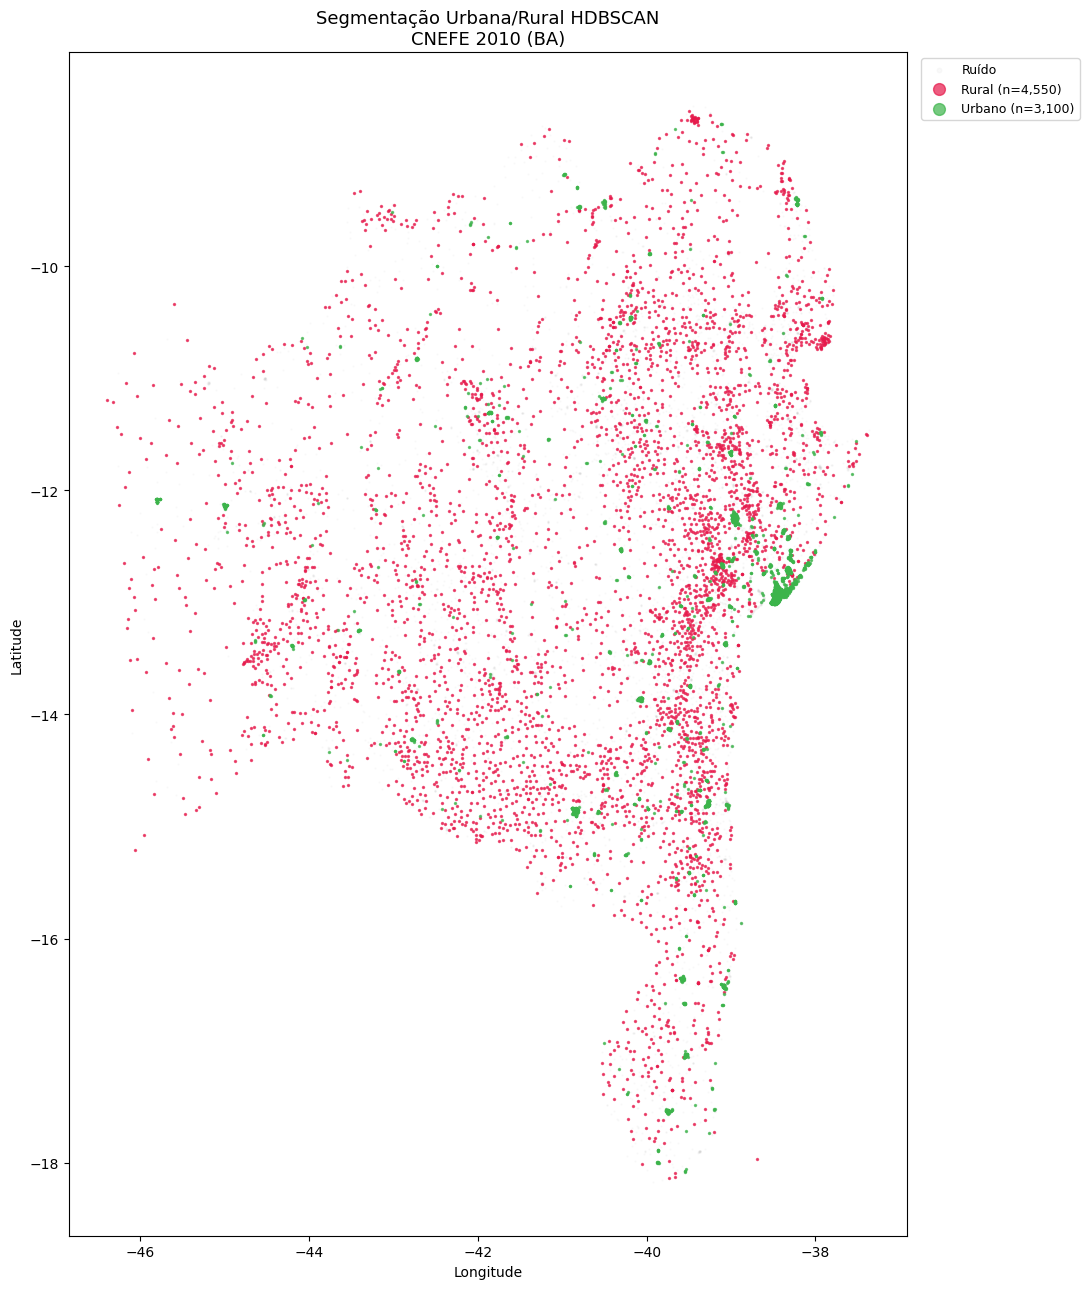

In [18]:
# Mapa clusters 2010 com cores fortes
CORES_FORTES = ['#e6194b','#3cb44b','#4363d8','#f58231','#911eb4',
                '#00b4d8','#f032e6','#bfef45','#9A6324','#469990',
                '#800000','#000075','#ff6b6b','#06d6a0','#ffd166']

df_2010_mapa = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet')
df_2022_coords = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')[
    ['COD_SETOR', 'lat_centroide', 'lon_centroide']
].copy()
df_2022_coords['cod_setor'] = df_2022_coords['COD_SETOR'].str[:-1]

df_2010_geo = df_2010_mapa.merge(
    df_2022_coords[['cod_setor', 'lat_centroide', 'lon_centroide']],
    on='cod_setor', how='inner'
)

nomes_unicos_10 = sorted(df_2010_geo[df_2010_geo['cluster'] != -1]['cluster_nome'].unique())
palette_10 = {n: CORES_FORTES[i % len(CORES_FORTES)] for i, n in enumerate(nomes_unicos_10)}

fig, ax = plt.subplots(figsize=(11, 13))
noise = df_2010_geo[df_2010_geo['cluster'] == -1]
ax.scatter(noise['lon_centroide'], noise['lat_centroide'], s=0.3, c='#cccccc', alpha=0.1, label='Ruído')

for nome in nomes_unicos_10:
    sub = df_2010_geo[df_2010_geo['cluster_nome'] == nome]
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
               s=2, alpha=0.7, color=palette_10[nome], label=f'{nome} (n={len(sub):,})')

ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title('Segmentação Urbana/Rural HDBSCAN\nCNEFE 2010 (BA)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/distribuicao_clusters_2010_ba.png', dpi=150, bbox_inches='tight')
plt.show()

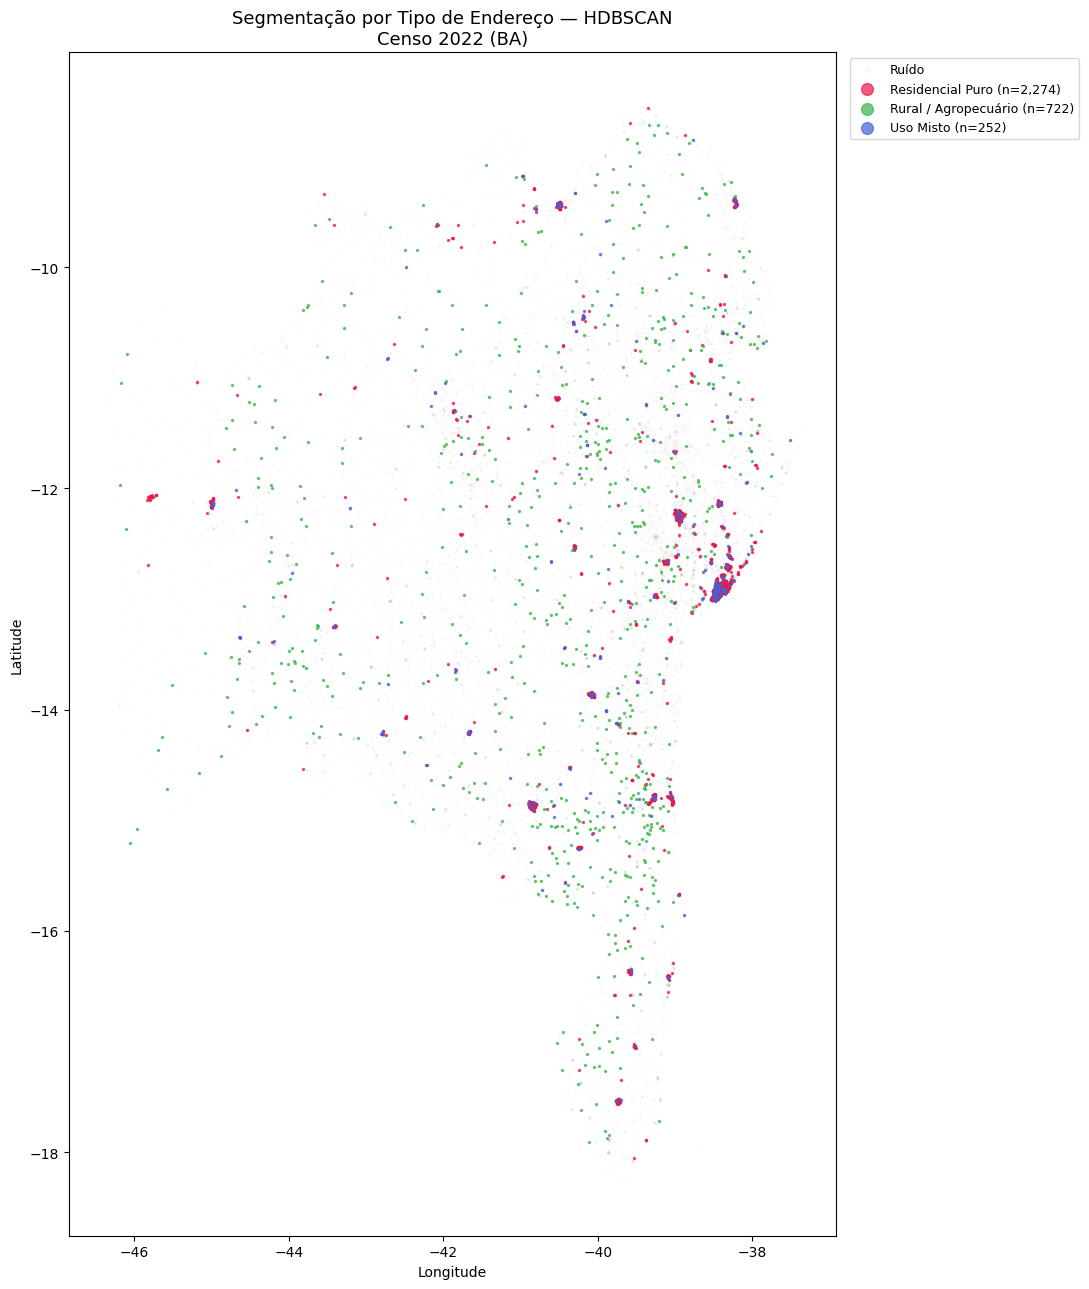

In [19]:
# Mapa clusters 2022 com cores fortes
df_2022_mapa = pd.read_parquet(OUTPUT_DIR / 'setores_clusterizados.parquet')
nomes_unicos_22 = sorted(df_2022_mapa[df_2022_mapa['cluster'] != -1]['cluster_nome'].unique())
palette_22 = {n: CORES_FORTES[i % len(CORES_FORTES)] for i, n in enumerate(nomes_unicos_22)}

fig, ax = plt.subplots(figsize=(11, 13))
noise_22 = df_2022_mapa[df_2022_mapa['cluster'] == -1]
ax.scatter(noise_22['lon_centroide'], noise_22['lat_centroide'], s=0.3, c='#cccccc', alpha=0.1, label='Ruído')

for nome in nomes_unicos_22:
    sub = df_2022_mapa[df_2022_mapa['cluster_nome'] == nome]
    ax.scatter(sub['lon_centroide'], sub['lat_centroide'],
               s=2, alpha=0.7, color=palette_22[nome], label=f'{nome} (n={len(sub):,})')

ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title('Segmentação por Tipo de Endereço — HDBSCAN\nCenso 2022 (BA)', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/distribuicao_clusters_2022_ba.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Salvar
df_2010.to_parquet(OUTPUT_DIR / 'setores_clusterizados_2010_ba.parquet', index=False)
print('Salvo: outputs/setores_clusterizados_2010_ba.parquet')

Salvo: outputs/setores_clusterizados_2010_ba.parquet


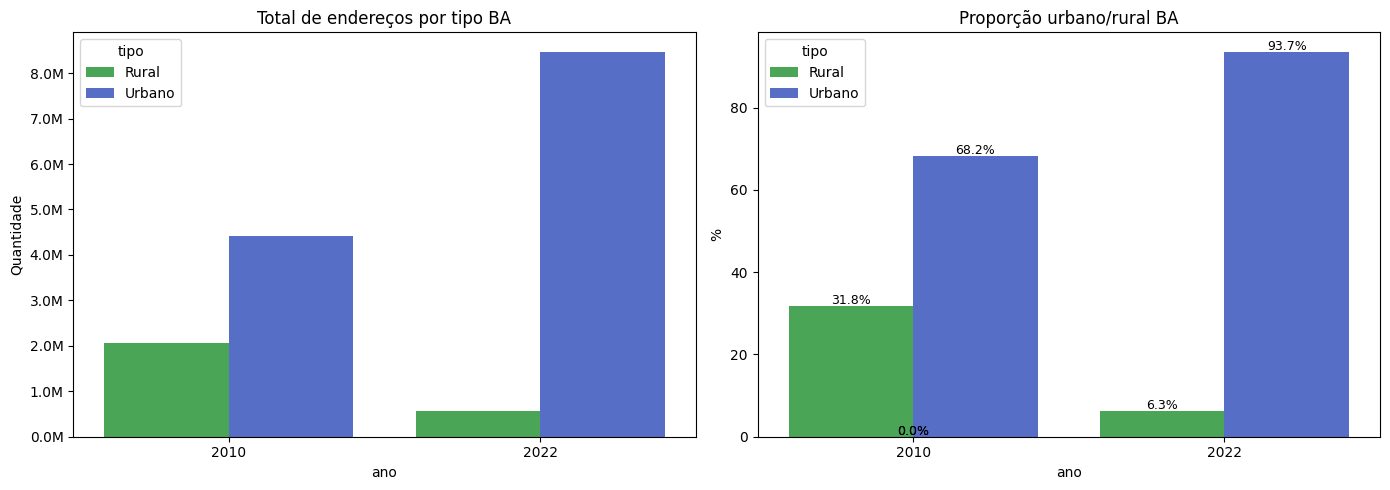

In [21]:
# Comparativo urbano/rural: total de endereços 2010 vs 2022
total_2010 = con.execute(f"""
    SELECT situacao, COUNT(*) as total
    FROM read_parquet({CNEFE_2010})
    WHERE uf = '29'
    GROUP BY situacao
""").df()
total_2010['ano']  = '2010'
total_2010['tipo'] = total_2010['situacao'].map({'1': 'Urbano', '2': 'Rural'})

total_2022 = con.execute("""
    SELECT
        CASE WHEN COD_ESPECIE = 3 THEN 'Rural' ELSE 'Urbano' END AS tipo,
        COUNT(*) as total
    FROM read_parquet('../data/censo 2022/29_BA.parquet')
    GROUP BY tipo
""").df()
total_2022['ano'] = '2022'

df_comp = pd.concat([
    total_2010[['ano', 'tipo', 'total']],
    total_2022[['ano', 'tipo', 'total']]
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras absolutas
sns.barplot(data=df_comp, x='ano', y='total', hue='tipo',
            palette={'Urbano': '#4363d8', 'Rural': '#3cb44b'}, ax=axes[0])
axes[0].set_title('Total de endereços por tipo BA')
axes[0].set_ylabel('Quantidade')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Barras percentuais
df_pct = df_comp.copy()
for ano in ['2010', '2022']:
    tot = df_pct[df_pct['ano'] == ano]['total'].sum()
    df_pct.loc[df_pct['ano'] == ano, 'pct'] = df_pct.loc[df_pct['ano'] == ano, 'total'] / tot * 100

sns.barplot(data=df_pct, x='ano', y='pct', hue='tipo',
            palette={'Urbano': '#4363d8', 'Rural': '#3cb44b'}, ax=axes[1])
axes[1].set_title('Proporção urbano/rural BA')
axes[1].set_ylabel('%')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height() + 0.5),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures/comparativo_urbano_rural_2010_2022_ba.png', dpi=150)
plt.show()